In [1]:
import bte
from bte import MATree, MATNode
from collections import Counter
import re
import numpy as np
from scipy.stats import multinomial
from Bio import Entrez, SeqIO
import pandas as pd
import io

In [2]:
# New updated tree with 2026 samples
tree = bte.MATree("/Users/reem/2026_updated_tree.pb")

Finished 'from_pb' in 137.6654 seconds


In [40]:
all_nodes = list(tree.depth_first_expansion())
print(len(all_nodes))

9197366


In [ ]:
print(tree.get_node("node_2172435").mutations)


In [42]:
rows = []
for node in all_nodes:
    rows.append({
        "node_id": node.id,
        "parent_id": node.parent.id if node.parent else None,
        "children": [child.id for child in node.children],
        "mutations": tree.get_node(node.id).mutations,
        "num_mutations": len(tree.get_node(node.id).mutations),
        "level": node.level,
        "branch_length": node.branch_length})
df_nodes = pd.DataFrame(rows)
df_nodes.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length
0,node_1,None,"[CHN/YN-0306-466/2020|MT396241.1|2020-03-06, D...",[],0,1,0.0
1,CHN/YN-0306-466/2020|MT396241.1|2020-03-06,node_1,[],[G15910T],1,2,1.0
2,DP0803|LC571037.1|2020-02-17,node_1,[],[G4162T],1,2,1.0
3,node_2,node_1,[England/LEED-2A8B52/2020|OA971832.1|2020-04-0...,[T13090C],1,2,1.0
4,England/LEED-2A8B52/2020|OA971832.1|2020-04-04,node_2,[],"[C1191T, C11674T]",2,3,2.0


In [43]:
df_nodes = df_nodes[df_nodes["num_mutations"] > 0]
len(df_nodes)


3719800

In [44]:
df_nodes.head(5)

,node_id,parent_id,children,mutations,num_mutations,level,branch_length
1,CHN/YN-0306-466/2020|MT396241.1|2020-03-06,node_1,[],[G15910T],1,2,1.0
2,DP0803|LC571037.1|2020-02-17,node_1,[],[G4162T],1,2,1.0
3,node_2,node_1,[England/LEED-2A8B52/2020|OA971832.1|2020-04-0...,[T13090C],1,2,1.0
4,England/LEED-2A8B52/2020|OA971832.1|2020-04-04,node_2,[],"[C1191T, C11674T]",2,3,2.0
5,England/SHEF-C06CE/2020|2020-03-25,node_2,[],[T15821C],1,3,1.0


In [17]:
df_nodes.to_csv("/Users/reem/bte_nodes.tsv", sep="\t", index=False)

In [45]:
def mut_to_class(s):
    return re.sub(r"(\w)(\d+)(\w)", r"\1>\3", s)


def classify_mutations(muts):
    muts = [mut_to_class(m) for m in muts]
    counts = Counter(muts)
    return counts



In [46]:
# Load mutational spectra
spectra = [
    {"name":"BA.1",
     "url": "https://raw.githubusercontent.com/theosanderson/molnupiravir/main/mutational_spectra/BA.1_SBS_spectrum_Ruis.csv"
    },
    {"name":"High G-to-A",
        "url": "https://raw.githubusercontent.com/theosanderson/molnupiravir/main/mutational_spectra/long_phylogenetic_branches/long_branch_spectrum_rescaled.csv"    
    },
]

In [47]:
def fetch_reference_genome(accession='NC_045512.2'):
    Entrez.email = "theo@theo.io"  
    handle = Entrez.efetch(db="nucleotide", id=accession, rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()
    return str(record.seq)
reference_genome = fetch_reference_genome("NC_045512.2")  # SARS-CoV-2 reference genome

In [ ]:
df_nodes = pd.read_csv("/Users/reem/bte_nodes.tsv", sep="\t")

In [48]:
# Remove brackets from mutations column and split by commas e.g. mutation now: ['G15910T']	
# Convert string list → actual list
df_nodes["mutations"] = df_nodes["mutations"].astype(str).str.strip("[]").str.replace("'", "",regex=False)

df_nodes["mutations"].head()

1            G15910T
2             G4162T
3            T13090C
4    C1191T, C11674T
5            T15821C
Name: mutations, dtype: object

In [49]:
def get_mut_type(mut_string):
    mut_string = mut_string.strip().strip("'''").strip('"').strip("'")
    if isinstance(mut_string, str) and len(mut_string) >= 3:
        return f"{mut_string[0]}>{mut_string[-1]}"
    else:
        return ''

df_nodes["subs"]=df_nodes["mutations"].apply(lambda x: ','.join(mut for mut in (get_mut_type(item) for item in x.split(',')) if mut) if isinstance(x, str) else '')
df_nodes["subs"]

1                              G>T
2                              G>T
3                              T>C
4                          C>T,C>T
5                              T>C
                    ...           
9197082                C>T,C>T,C>T
9197083                    G>A,A>G
9197084                    T>C,T>C
9197085            G>T,A>T,G>T,C>T
9197086    G>A,T>A,C>A,C>T,C>T,T>C
Name: subs, Length: 3719800, dtype: object

In [50]:
# Get all mutation counts
df_nodes["Counts"] = df_nodes["subs"].str.strip().apply(lambda x: dict(Counter(x.strip().split(","))))
df_nodes["Counts"].head(20)

1     {'G>T': 1}
2     {'G>T': 1}
3     {'T>C': 1}
4     {'C>T': 2}
5     {'T>C': 1}
6     {'T>C': 1}
7     {'G>T': 1}
9     {'G>T': 1}
10    {'G>A': 1}
11    {'C>T': 1}
12    {'G>T': 1}
14    {'C>T': 1}
23    {'T>C': 1}
24    {'G>A': 1}
30    {'C>T': 1}
31    {'G>A': 2}
32    {'G>A': 1}
33    {'T>C': 1}
37    {'C>T': 1}
38    {'C>T': 1}
Name: Counts, dtype: object

In [ ]:
node_id = "node_2172435"
df_nodes.loc[df_nodes["node_id"] == node_id, "Counts"].values[0]

In [51]:
# Calculate LLR
probs_df=pd.read_csv("/Users/reem/Downloads/estimated_mutation_distribution.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["MutationType"].str.replace("→",">").tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["Counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["LLR"] = llr_list
df_nodes.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR
1,CHN/YN-0306-466/2020|MT396241.1|2020-03-06,node_1,[],G15910T,1,2,1.0,G>T,{'G>T': 1},-1.509730
2,DP0803|LC571037.1|2020-02-17,node_1,[],G4162T,1,2,1.0,G>T,{'G>T': 1},-1.509730
3,node_2,node_1,[England/LEED-2A8B52/2020|OA971832.1|2020-04-0...,T13090C,1,2,1.0,T>C,{'T>C': 1},-0.528901
4,England/LEED-2A8B52/2020|OA971832.1|2020-04-04,node_2,[],"C1191T, C11674T",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360
5,England/SHEF-C06CE/2020|2020-03-25,node_2,[],T15821C,1,3,1.0,T>C,{'T>C': 1},-0.528901


In [37]:
df_nodes.loc[df_nodes["node_id"] == "node_2172435", "LLR"].values[0]

np.float64(-1.3767190801427063)

In [16]:
df_nodes["mutations"].head()

1            G15910T
2             G4162T
3            T13090C
4    C1191T, C11674T
5            T15821C
Name: mutations, dtype: object

In [52]:
def get_context(genome_seq, mutation):
    # mutation must be at least ref + digits + alt
    if not isinstance(mutation, str):
        return ""
    mutation = mutation.strip().strip("'''").strip('"').strip("'")

    # must start with a nucleotide
    if mutation[0] not in "ACGT":
        return ""

    # must end with a nucleotide
    if mutation[-1] not in "ACGT":
        return ""

    # extract numeric middle part
    middle = mutation[1:-1]
    if not middle.isdigit():
        return ""
    pos = int(middle) - 1
    context = genome_seq[pos-1:pos+2]  # get the base before and after
    return context
df_nodes["context"] = df_nodes["mutations"].apply(lambda x: ','.join(mut for mut in (get_context(reference_genome, item) for item in x.split(',')) if mut) if isinstance(x, str) else '')
df_nodes["context"]


1                              TGA
2                              TGG
3                              ATG
4                          CCA,ACT
5                              ATG
                    ...           
9197082                TCA,ACT,GCT
9197083                    GGA,TAC
9197084                    ATT,ATC
9197085            AGA,TAG,AGG,ACC
9197086    TGA,ATG,ACC,ACC,ACC,GTA
Name: context, Length: 3719800, dtype: object

In [53]:
def spectrum(subs, contexts):
    if not isinstance(subs, str) or not isinstance(contexts, str):
        return ''
    if not subs.strip() or not contexts.strip():
        return ''
    subs= [s.strip() for s in subs.split(',')]
    contexts = [c.strip() for c in contexts.split(',')]
    spectra = []
    for mutation, context in zip(subs, contexts): 
        if len(context) >= 2 and mutation:
            spectra.append(f"{context[0]}[{mutation}]{context[-1]}")
        else:
            continue
    return ','.join(spectra)
df_nodes["spectrum"] = df_nodes.apply(lambda row: spectrum(row["subs"], row["context"]), axis=1)
df_nodes["spectrum"].head(20)

1             T[G>T]A
2             T[G>T]G
3             A[T>C]G
4     C[C>T]A,A[C>T]T
5             A[T>C]G
6             T[T>C]T
7             T[G>T]A
9             C[G>T]T
10            A[G>A]T
11            C[C>T]C
12            A[G>T]T
14            A[C>T]C
23            G[T>C]T
24            A[G>A]T
30            T[C>T]T
31    A[G>A]C,A[G>A]C
32            A[G>A]G
33            T[T>C]T
37            A[C>T]G
38            T[C>T]A
Name: spectrum, dtype: object

In [54]:
def count_GtoA(spectrum):
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'G>A':
            counts[mut]+=1
    return counts
df_nodes["GtoA_counts"] = df_nodes["spectrum"].apply(count_GtoA)
df_nodes["GtoA_counts"].head(20)

1                 {}
2                 {}
3                 {}
4                 {}
5                 {}
6                 {}
7                 {}
9                 {}
10    {'A[G>A]T': 1}
11                {}
12                {}
14                {}
23                {}
24    {'A[G>A]T': 1}
30                {}
31    {'A[G>A]C': 2}
32    {'A[G>A]G': 1}
33                {}
37                {}
38                {}
Name: GtoA_counts, dtype: object

In [55]:
#Calculate G>A LLRS using prob_table:

probs_df=pd.read_csv("/Users/reem/GtoAprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["GtoA_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["G>A_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"G>A_llr"].head(10))

1     0.000000
2     0.000000
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.000000
9     0.000000
10   -0.337129
11    0.000000
Name: G>A_llr, dtype: float64


In [56]:
def count_AtoG(spectrum):   # spectrum eg. "C[A>G]T,T[C>T]G"
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'A>G':
            counts[mut]+=1
    return counts
df_nodes["AtoG_counts"] = df_nodes["spectrum"].apply(count_AtoG)
df_nodes["AtoG_counts"].head(20)

1     {}
2     {}
3     {}
4     {}
5     {}
6     {}
7     {}
9     {}
10    {}
11    {}
12    {}
14    {}
23    {}
24    {}
30    {}
31    {}
32    {}
33    {}
37    {}
38    {}
Name: AtoG_counts, dtype: object

In [57]:
probs_df=pd.read_csv("/Users/reem/AtoGprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["AtoG_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["A>G_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"A>G_llr"])

1          0.000000
2          0.000000
3          0.000000
4          0.000000
5          0.000000
             ...   
9197082    0.000000
9197083   -0.927152
9197084    0.000000
9197085    0.000000
9197086    0.000000
Name: A>G_llr, Length: 3719800, dtype: float64


In [58]:
def count_CtoT(spectrum):
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'C>T':
            counts[mut]+=1
    return counts
df_nodes["CtoT_counts"] = df_nodes["spectrum"].apply(count_CtoT)
df_nodes["CtoT_counts"].head(20)

1                               {}
2                               {}
3                               {}
4     {'C[C>T]A': 1, 'A[C>T]T': 1}
5                               {}
6                               {}
7                               {}
9                               {}
10                              {}
11                  {'C[C>T]C': 1}
12                              {}
14                  {'A[C>T]C': 1}
23                              {}
24                              {}
30                  {'T[C>T]T': 1}
31                              {}
32                              {}
33                              {}
37                  {'A[C>T]G': 1}
38                  {'T[C>T]A': 1}
Name: CtoT_counts, dtype: object

In [59]:
probs_df=pd.read_csv("/Users/reem/CtoTprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["CtoT_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["C>T_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"C>T_llr"])

1          0.000000
2          0.000000
3          0.000000
4         -0.351044
5          0.000000
             ...   
9197082    0.082310
9197083    0.000000
9197084    0.000000
9197085    0.027145
9197086    0.054291
Name: C>T_llr, Length: 3719800, dtype: float64


In [60]:
def count_TtoC(spectrum):
    counts = Counter()
    muts = spectrum.split(",")
    for mut in muts:
        if mut[2:5] == 'T>C':
            counts[mut]+=1
    return counts
df_nodes["TtoC_counts"] = df_nodes["spectrum"].apply(count_TtoC)
df_nodes["TtoC_counts"].head(20)

1                 {}
2                 {}
3     {'A[T>C]G': 1}
4                 {}
5     {'A[T>C]G': 1}
6     {'T[T>C]T': 1}
7                 {}
9                 {}
10                {}
11                {}
12                {}
14                {}
23    {'G[T>C]T': 1}
24                {}
30                {}
31                {}
32                {}
33    {'T[T>C]T': 1}
37                {}
38                {}
Name: TtoC_counts, dtype: object

In [61]:
probs_df=pd.read_csv("/Users/reem/TtoCprobs_new.tsv", delimiter="\t")
pM=probs_df["Molnupiravir"].to_numpy(dtype=float)
pN=probs_df["Normal"].to_numpy(dtype=float)
mut_types=probs_df["Mutational_Context"].tolist()

def get_likelihood_ratio(counts,pM,pN):
    counts=np.array(counts,dtype=float)
    llM= float(multinomial.logpmf(counts, n=np.sum(counts), p=pM))
    llN = float(multinomial.logpmf(counts, n=np.sum(counts), p=pN))
    llr=llM-llN
    return llr
llr_list = []
for counts_dict in df_nodes["TtoC_counts"]:
    counts = [counts_dict.get(mt, 0) for mt in mut_types]
    llr = get_likelihood_ratio(counts,pM,pN)
    llr_list.append(llr)
df_nodes["T>C_llr"] = llr_list
df_nodes.head()

print(df_nodes[f"T>C_llr"])

1          0.000000
2          0.000000
3         -0.356234
4          0.000000
5         -0.356234
             ...   
9197082    0.000000
9197083    0.000000
9197084   -0.856558
9197085    0.000000
9197086   -0.345288
Name: T>C_llr, Length: 3719800, dtype: float64


In [62]:
df_nodes["sum_llrs"] = df_nodes["LLR"] + df_nodes["G>A_llr"] + df_nodes["A>G_llr"] + df_nodes["C>T_llr"] + df_nodes["T>C_llr"]
df_nodes.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,spectrum,GtoA_counts,G>A_llr,AtoG_counts,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs
1,CHN/YN-0306-466/2020|MT396241.1|2020-03-06,node_1,[],G15910T,1,2,1.0,G>T,{'G>T': 1},-1.509730,...,T[G>T]A,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730
2,DP0803|LC571037.1|2020-02-17,node_1,[],G4162T,1,2,1.0,G>T,{'G>T': 1},-1.509730,...,T[G>T]G,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730
3,node_2,node_1,[England/LEED-2A8B52/2020|OA971832.1|2020-04-0...,T13090C,1,2,1.0,T>C,{'T>C': 1},-0.528901,...,A[T>C]G,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135
4,England/LEED-2A8B52/2020|OA971832.1|2020-04-04,node_2,[],"C1191T, C11674T",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,"C[C>T]A,A[C>T]T",{},0.0,{},0.0,"{'C[C>T]A': 1, 'A[C>T]T': 1}",-0.351044,{},0.000000,0.521315
5,England/SHEF-C06CE/2020|2020-03-25,node_2,[],T15821C,1,3,1.0,T>C,{'T>C': 1},-0.528901,...,A[T>C]G,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135


In [63]:
df_nodes["sum_contexts"] = df_nodes["G>A_llr"] + df_nodes["A>G_llr"] + df_nodes["C>T_llr"] + df_nodes["T>C_llr"]
df_nodes.head() 

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,GtoA_counts,G>A_llr,AtoG_counts,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts
1,CHN/YN-0306-466/2020|MT396241.1|2020-03-06,node_1,[],G15910T,1,2,1.0,G>T,{'G>T': 1},-1.509730,...,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730,0.000000
2,DP0803|LC571037.1|2020-02-17,node_1,[],G4162T,1,2,1.0,G>T,{'G>T': 1},-1.509730,...,{},0.0,{},0.0,{},0.000000,{},0.000000,-1.509730,0.000000
3,node_2,node_1,[England/LEED-2A8B52/2020|OA971832.1|2020-04-0...,T13090C,1,2,1.0,T>C,{'T>C': 1},-0.528901,...,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135,-0.356234
4,England/LEED-2A8B52/2020|OA971832.1|2020-04-04,node_2,[],"C1191T, C11674T",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,{},0.0,{},0.0,"{'C[C>T]A': 1, 'A[C>T]T': 1}",-0.351044,{},0.000000,0.521315,-0.351044
5,England/SHEF-C06CE/2020|2020-03-25,node_2,[],T15821C,1,3,1.0,T>C,{'T>C': 1},-0.528901,...,{},0.0,{},0.0,{},0.000000,{'A[T>C]G': 1},-0.356234,-0.885135,-0.356234


In [52]:
df_nodes.to_csv("/Users/reem/bte_26_sumllrs.tsv", sep="\t", index=False)

In [3]:
# Merge metafitch output with bte output to get metadata for the nodes in the tree
metafitch_out = pd.read_csv("/Users/reem/merged_metafitch_strict.tsv", sep = "\t")

In [4]:
metafitch_out.rename(columns={"strain": "node_id"}, inplace=True)


In [6]:
# Merge metafitch output with bte output on bte_nodes
merged = pd.merge(df_nodes, metafitch_out, on="node_id", how="left")
merged.head()


,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,AtoG_counts,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],"""G15910T""",1,2,1.0,G>T,{'G>T': 1},-1.509730,...,Counter(),0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],"""G4162T""",1,2,1.0,G>T,{'G>T': 1},-1.509730,...,Counter(),0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,"""T13090C""",1,2,1.0,T>C,{'T>C': 1},-0.528901,...,Counter(),0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"""C1191T"", ""C11674T""",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,Counter(),0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],"""T15821C""",1,3,1.0,T>C,{'T>C': 1},-0.528901,...,Counter(),0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020


In [78]:
len(merged)

8943696

In [89]:
def get_descendant_leaves(root_node):
    """
    Return all leaf sample IDs below an internal node.
    """
    leaves =[]
    stack = [root_node]
    while stack:
        node = stack.pop()

        if len(node.children) == 0:
            leaves.append(node.id)
            continue
        for child in node.children:
            child_node = tree.get_node(child.id) if hasattr(child, "id") else tree.get_node(child)
            if child_node is not None:
                stack.append(child)
    return leaves

In [7]:
def get_parent_id(node):
    if node.parent:
        return node.parent.id if isinstance(node.parent, MATNode) else node.parent
    else:
        return None

In [ ]:
def get_descendant_leaves(root_node, tree):
    leaves = []
    stack = [root_node]

    while stack:
        node = stack.pop()

        if len(node.children) == 0:
            leaves.append(node.id)
            continue

        for child in node.children:
            child_node = tree.get_node(child.id) if hasattr(child, "id") else tree.get_node(child)
            if child_node is not None:
                stack.append(child_node)

    return leaves
def get_descendant_count(n):
    node = tree.get_node(n)
    if node is None:
        return None  # or 0, depending on what you want
    return len(get_descendant_leaves(node, tree))

In [ ]:
merged["num_descendants"] = merged["node_id"].apply(get_descendant_count)
merged.head(10)

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,A>G_llr,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants
0,Yunnan/0306-466/2020|EPI_ISL_429239|2020-03-06,node_1,[],"""G15910T""",1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,China,2020,1
1,Japan/DP0803/2020|EPI_ISL_416630|2020-02-17,node_1,[],"""G4162T""",1,2,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,NaN,2020,1
2,node_2,node_1,['England/LEED-2A8B52/2020|EPI_ISL_539074|2020...,"""T13090C""",1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,2
3,England/LEED-2A8B52/2020|EPI_ISL_539074|2020-0...,node_2,[],"""C1191T"", ""C11674T""",2,3,2.0,"C>T,C>T",{'C>T': 2},0.872360,...,0.0,"Counter({'C[C>T]A': 1, 'A[C>T]T': 1})",-0.351044,Counter(),0.000000,0.521315,-0.351044,England,2020,1
4,England/SHEF-C06CE/2020|EPI_ISL_420245|2020-03-25,node_2,[],"""T15821C""",1,3,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'A[T>C]G': 1}),-0.356234,-0.885135,-0.356234,England,2020,1
5,node_3,node_1,"['node_4', 'node_5', 'node_8', 'England/LCST-2...","""T4949C""",1,2,1.0,T>C,{'T>C': 1},-0.528901,...,0.0,Counter(),0.000000,Counter({'T[T>C]T': 1}),0.628259,0.099358,0.628259,"nan, Ireland, England, Wales",0,70
6,node_4,node_3,['England/SHEF-C07F8/2020|EPI_ISL_420175|2020-...,"""G6080T""",1,3,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,England,2020,2
7,England/SHEF-C0145/2020|EPI_ISL_420230|2020-03-25,node_4,[],"""G15038T""",1,4,1.0,G>T,{'G>T': 1},-1.509730,...,0.0,Counter(),0.000000,Counter(),0.000000,-1.509730,0.000000,England,2020,1
8,node_5,node_3,"['node_6', 'England/SHEF-D06E9/2020|OY366892.1...","""G6734A""",1,3,1.0,G>A,{'G>A': 1},0.505173,...,0.0,Counter(),0.000000,Counter(),0.000000,0.168044,-0.337129,England,2020,12
9,node_6,node_5,['USA/TX-HHD-4392170/2020|OM181113.1|2020-06-2...,"""C28472T""",1,4,1.0,C>T,{'C>T': 1},0.436180,...,0.0,Counter({'C[C>T]C': 1}),-0.585048,Counter(),0.000000,-0.148868,-0.585048,England,2020,2


In [29]:
# Test on a single node
test_node = "node_1526658"
print(merged[merged["node_id"] == test_node])

              node_id     parent_id  \
3432384  node_1526658  node_1526657   

                                                  children  mutations  \
3432384  ['Australia/QLD0x00F8B4/2022|EPI_ISL_13612268|...  "C21622T"   

         num_mutations  level  branch_length subs      Counts      LLR  ...  \
3432384              1     43            1.0  C>T  {'C>T': 1}  0.43618  ...   

        A>G_llr              CtoT_counts   C>T_llr  TtoC_counts T>C_llr  \
3432384     0.0  Counter({'C[C>T]A': 1}) -0.268934    Counter()     0.0   

         sum_llrs sum_contexts    country  date  num_descendants  
3432384  0.167246    -0.268934  Australia  2022               34  

[1 rows x 25 columns]


In [ ]:
# Clean mutations column (remove double and triple quotes) to convert string list → actual list
import re

def clean_mutations(x):
    if pd.isna(x):
        return []
    x = str(x)
    x = re.sub(r'"{2,}', '"', x)   # fix triple quotes
    x = x.replace('"', '')
    return [m.strip() for m in x.split(",") if m.strip()]

merged["mutations"] = merged["mutations"].apply(clean_mutations)

In [10]:
# SAVE FINAL OUTPUT
merged.to_csv("/Users/reem/merged_bte_final_strict.tsv", sep="\t", index=False)


In [ ]:
mov_nodes = merged[(merged["LLR"] > 3) & (merged["sum_contexts"] > 2)]
print(len(mov_nodes))

mov_cluster_roots = []                                  # A cluster root is a node that is in mov_nodes but its parent is not in mov_nodes (or it has no parent)
                                                        # To avoid nested clusters and double counting
for node in tree.depth_first_expansion():
    if node.id not in mov_nodes["node_id"].values:
        continue
    parent_id = get_parent_id(node)
    if parent_id is None or parent_id not in mov_nodes["node_id"].values:
        mov_cluster_roots.append(node.id)
                                                            
print(len(mov_cluster_roots))
print(mov_cluster_roots)


In [36]:
mov_nodes = merged[(merged["LLR"] > 3) & (merged["sum_contexts"] > 2)]
mov_node_ids = set(mov_nodes["node_id"])
print(len(mov_nodes))
mov_cluster_roots = []

for node_id in mov_node_ids:
    node = tree.get_node(node_id)
    if node is None:
        continue  # safety

    parent_id = get_parent_id(node)

    if parent_id is None or parent_id not in mov_node_ids:
        mov_cluster_roots.append(node_id)
print(len(mov_cluster_roots))
print(mov_cluster_roots)

1001
995
['hCoV-19/Japan/PG-449898/2023|2023-02-07|2023-02-22', 'hCoV-19/Australia/ACT8430/2022|2022-09-05|2022-10-24', 'node_1529999', 'hCoV-19/Japan/PG-364675/2022|2022-09-18|2022-10-12', 'node_1750798', 'hCoV-19/USA/NH-CDCBI-CRSP_RR7JUYUIRRRNWNAQ/2022|2022-09-13|2022-09-27', 'Japan/PG-407998/2022|EPI_ISL_16138501|2022-12-02', 'Australia/VIC-VIDRL-00004961/2022|EPI_ISL_17826392|2022-12-11', 'USA/OK-PHL-0024579/2022|EPI_ISL_17107842|2022-12-26', 'node_801573', 'hCoV-19/Japan/PG-587497/2023|2023-12-14|2024-01-11', 'node_2618695', 'SouthKorea/KDCA277606/2023|EPI_ISL_18687076|2023-11-20', 'hCoV-19/Scotland/QEUH-3890EA0/2022|2022-02-27|2022-03-08', 'hCoV-19/Japan/PG-462878/2023|2023-03-01|2023-03-19', 'Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|2020-09-22', 'USA/MN-MDH-25368/2022|EPI_ISL_13044618|2022-05-21', 'Australia/SA465025/2022|EPI_ISL_15382020|2022-10-06', 'node_2558836', 'hCoV-19/Australia/WA15636/2023|2023-11-13|2024-01-05', 'hCoV-19/Japan/PG-439872/2023|2023-01-18|2023-02-03'

In [35]:
mov_cluster_roots = pd.DataFrame(mov_cluster_roots, columns=["node_id"])
mov_cluster_roots.to_csv("/Users/reem/mov_cluster_roots.tsv", sep="\t", index=False)

In [18]:
mov_relaxed = merged[merged["sum_llrs"] > 6]
mov_ids = set(mov_relaxed["node_id"])

mov_cluster = []

for node in tree.depth_first_expansion():
    if node.id not in mov_ids:
        continue
    parent_id = get_parent_id(node)
    if parent_id is None or parent_id not in mov_ids:
        mov_cluster.append(node.id)
                                                            
print(len(mov_cluster))
print(mov_cluster)

1210
['Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|2021-11-04', 'node_143150', 'USA/NC-CORVASEQ-DH-182M245000001406/2021|OL866144.1|2021-07-02', 'Turkey/HSGM-B3574/2021|EPI_ISL_2968466|2021-03-30', 'hCoV-19/Ecuador/INSPI-M1A/2020|2020-11-24|2022-04-22', 'India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708373|2020-09-28', 'Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|2020-09-22', 'deer/USA/NY-WTD_165681/2021|EPI_ISL_13658809|2021-11-20', 'node_331403', 'node_359830', 'hCoV-19/Australia/WA6668/2022|2022-08-19|2022-09-06', 'node_546047', 'England/ARCH-002550F9/2022|OY964502.1|2022-01-12', 'hCoV-19/USA/MN-CDC-IBX024513492461/2022|2022-01-31|2022-02-17', 'Denmark/DCGC-369053/2022|EPI_ISL_10012883|2022-02-08', 'Denmark/DCGC-369124/2022|EPI_ISL_10013073|2022-02-09', 'Denmark/DCGC-651260/2022|EPI_ISL_18152107|2022-01-31', 'Australia/VIC46621/2022|EPI_ISL_11630027|2022-03-07', 'England/NORT-YNNJM4E/2022|OY887762.1|2022-03-09', 'England/PLYM-342FAF1/2022|EPI_ISL_9367297|2022-01-24', 'hCoV-19/England/

In [47]:
cluster_df = pd.DataFrame({
    "node_id": mov_cluster_roots,
    "cluster_size": [len(get_descendant_leaves(tree.get_node(n), tree)) for n in mov_cluster_roots]})
len(cluster_df)

995

In [37]:
non_roots = []

for node_id in mov_node_ids:
    node = tree.get_node(node_id)
    parent_id = get_parent_id(node)
    
    if parent_id in mov_node_ids:
        non_roots.append((node_id, parent_id))

print(len(non_roots))  # should be 6
print(non_roots[:10])

6
[('hCoV-19/Australia/WA9133/2022|2022-10-31|2022-11-29', 'node_1618923'), ('node_1331125', 'node_1331124'), ('node_1526661', 'node_1526660'), ('hCoV-19/Australia/WA9976/2022|2022-12-08|2022-12-19', 'node_1526660'), ('Thailand/CU-AMV24/2024|EPI_ISL_19527023|2024-02-07', 'node_2504543'), ('Australia/VIC61450/2022|EPI_ISL_13276187|2022-05-28', 'node_2748096')]


In [38]:
for node_id in mov_cluster_roots:
    node = tree.get_node(node_id)
    children = node.children if node else []
    
    child_ids = [
        c.id if hasattr(c, "id") else c
        for c in children
    ]
    
    print(node_id, "→", child_ids)

hCoV-19/Japan/PG-449898/2023|2023-02-07|2023-02-22 → []
hCoV-19/Australia/ACT8430/2022|2022-09-05|2022-10-24 → []
node_1529999 → ['Slovakia/RNA/2022|OX049558.1|2022-04-14', 'Slovakia/BA_22_00029125/2022|EPI_ISL_13229021|2022-04-14']
hCoV-19/Japan/PG-364675/2022|2022-09-18|2022-10-12 → []
node_1750798 → ['Australia/TAS003273/2022|EPI_ISL_14650793|2022-08-08', 'Australia/TAS003552/2022|EPI_ISL_14930774|2022-08-18', 'Australia/TAS003553/2022|EPI_ISL_14930775|2022-08-14']
hCoV-19/USA/NH-CDCBI-CRSP_RR7JUYUIRRRNWNAQ/2022|2022-09-13|2022-09-27 → []
Japan/PG-407998/2022|EPI_ISL_16138501|2022-12-02 → []
Australia/VIC-VIDRL-00004961/2022|EPI_ISL_17826392|2022-12-11 → []
USA/OK-PHL-0024579/2022|EPI_ISL_17107842|2022-12-26 → []
node_801573 → ['England/NORT-YNBSO3M/2022|OY923825.1|2022-02-02', 'England/NORT-YNBSO3M/2022|EPI_ISL_9962444|2022']
hCoV-19/Japan/PG-587497/2023|2023-12-14|2024-01-11 → []
node_2618695 → ['Germany/NW-RKI-I-635082/2022|EPI_ISL_11478433|2022-03-15', 'Germany/IMS-10150-CVDP-D9

In [19]:
cluster = pd.DataFrame({
    "node_id": mov_cluster,
    "cluster_size": [len(get_descendant_leaves(tree.get_node(n))) for n in mov_cluster]})
len(cluster)

1210

In [48]:
# Merge cluster sizes back to mov_nodes
mov_roots = pd.merge(mov_nodes, cluster_df, on="node_id", how="inner")
print(len(mov_roots))
print(mov_roots.head())


995
                                             node_id    parent_id children  \
0  Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...   node_24835       []   
1  India/KA-042197_2_S61_R1_001/2020|EPI_ISL_1708...  node_243043       []   
2  Mexico/CMX-INER-IBT-0454/2020|EPI_ISL_3758018|...  node_243370       []   
3  USA/MA-CDC-LC0049944/2021|EPI_ISL_1926374|2021...  node_254525       []   
4  hCoV-19/Australia/WA6668/2022|2022-08-19|2022-...  node_543775       []   

                                           mutations  num_mutations  level  \
0  [C1758T, C7600T, G8984A, C11200T, C16667T, C17...             13     26   
1  [C8299T, C10369T, C10714T, C12528T, C14576T, C...              9     13   
2  [C676T, C1387T, C5986T, G8990A, C9487T, C10790...             10     14   
3  [C2110T, C6954T, T7984C, C8809T, C8890T, C1012...             10     24   
4  [G428A, G1156A, C1282T, G1358A, T1792C, C2262T...             61     37   

   branch_length                                          

In [58]:
mov_roots[mov_roots["cluster_size"].isna()]

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants,cluster_size


In [59]:
len(mov_roots)

995

In [20]:
# Merge cluster sizes back to mov_nodes
mov_relaxed = pd.merge(mov_relaxed, cluster, on="node_id", how="left")
mov_relaxed.head()

,node_id,parent_id,children,mutations,num_mutations,level,branch_length,subs,Counts,LLR,...,CtoT_counts,C>T_llr,TtoC_counts,T>C_llr,sum_llrs,sum_contexts,country,date,num_descendants,cluster_size
0,Tanzania/NIMR-R40128/2021|EPI_ISL_19837217|202...,node_24835,[],"'C1758T', 'C7600T', 'G8984A', 'C11200T', 'C166...",13,26,13.0,"C>T,C>T,G>A,C>T,C>T,C>T,C>T,C>T,C>T,C>T,C>T,T>...","{'C>T': 11, 'G>A': 1, 'T>C': 1}",4.774250,...,"Counter({'A[C>T]T': 4, 'G[C>T]A': 3, 'C[C>T]A'...",0.909696,Counter({'C[T>C]T': 1}),0.833280,7.027866,2.253616,Tanzania,2021,1,1.0
1,node_143150,node_143148,['USA/PA-0258/2021|EPI_ISL_10657990|2021-07-23...,"'C5183T', 'C5365T', 'C6813T', 'C7029T', 'C7279...",23,17,23.0,"C>T,C>T,C>T,C>T,C>T,G>A,C>T,C>T,C>T,C>T,C>T,C>...","{'C>T': 19, 'G>A': 3, 'A>T': 1}",8.293204,...,"Counter({'A[C>T]A': 5, 'T[C>T]T': 5, 'T[C>T]A'...",-1.220422,Counter(),0.000000,8.094339,-0.198865,USA,2021,2,2.0
2,USA/NC-CORVASEQ-DH-182M245000001406/2021|OL866...,node_153531,[],"'C337T', 'G3527A', 'C3768T', 'C3902T', 'C6720T...",20,19,20.0,"C>T,G>A,C>T,C>T,C>T,C>T,C>A,C>T,G>A,C>T,G>A,C>...","{'C>T': 15, 'G>A': 4, 'C>A': 1}",7.276801,...,"Counter({'A[C>T]T': 5, 'A[C>T]A': 3, 'T[C>T]T'...",0.785146,Counter(),0.000000,7.105877,-0.170924,USA,2021,1,1.0
3,Turkey/HSGM-B3574/2021|EPI_ISL_2968466|2021-03-30,node_157667,[],"'C2462T', 'A3058G', 'A4595G', 'A9235G', 'G1185...",16,8,16.0,"C>T,A>G,A>G,A>G,G>A,T>C,C>T,A>G,G>A,G>A,C>T,G>...","{'C>T': 4, 'A>G': 5, 'G>A': 5, 'T>C': 2}",2.160544,...,"Counter({'T[C>T]T': 1, 'C[C>T]A': 1, 'A[C>T]A'...",-0.028852,"Counter({'T[T>C]T': 1, 'A[T>C]G': 1})",0.272025,6.762409,4.601865,Turkey,2021,1,1.0
4,hCoV-19/Ecuador/INSPI-M1A/2020|2020-11-24|2022...,node_226010,[],"'C2306T', 'C5400T', 'C6730T', 'G6894A', 'T7689...",22,11,22.0,"C>T,C>T,C>T,G>A,T>C,C>T,T>C,G>A,G>A,T>C,C>T,T>...","{'C>T': 9, 'G>A': 7, 'T>C': 3, 'T>A': 2, 'A>G'...",2.953517,...,"Counter({'G[C>T]T': 2, 'A[C>T]A': 2, 'A[C>T]T'...",0.059489,"Counter({'C[T>C]T': 2, 'C[T>C]A': 1})",1.415978,7.903479,4.949961,Ecuador,2020,1,1.0


In [60]:
mov_roots.to_csv("/Users/reem/merged_bte_mov_strict.tsv", sep = "\t", index=False)


In [21]:
mov_relaxed.to_csv("merged_bte_mov_relaxed.tsv", sep = "\t", index=False)

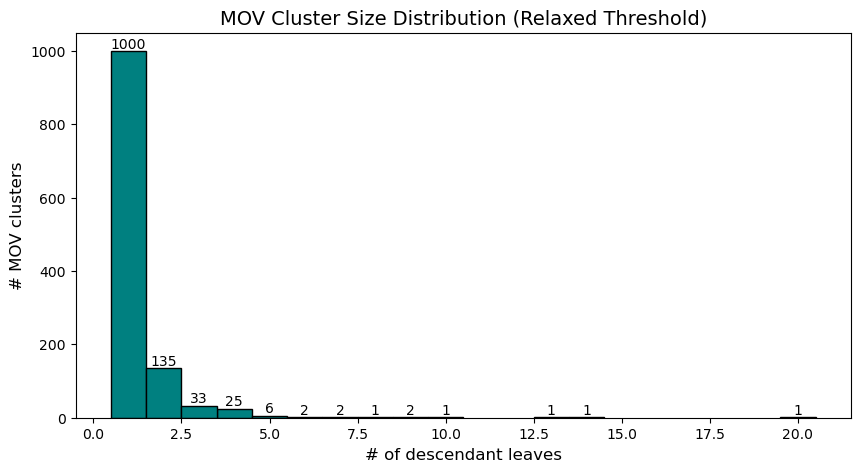

<Figure size 640x480 with 0 Axes>

In [22]:
# Repeat the figure but with crude threshold MOV clusters instead of strict threshold MOV clusters

mov_relaxed = pd.read_csv("merged_bte_mov_relaxed.tsv", sep="\t")

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np                  

# size counts
size_counts = Counter(mov_relaxed["cluster_size"])

sizes = size_counts.keys()
counts = size_counts.values()

plt.figure(figsize=(10,5))

bars = plt.bar(
    sizes,
    counts,
    width=1.0,
    color="teal",
    edgecolor="black"
)
x_values = np.arange(len(sizes))
plt.xlabel("# of descendant leaves", fontsize=12)
plt.ylabel("# MOV clusters", fontsize=12)
plt.title("MOV Cluster Size Distribution (Relaxed Threshold)", fontsize=14)

ax = plt.gca()
ax.bar_label(bars, label_type='edge', color='black')
plt.show()

plt.tight_layout()
plt.show()

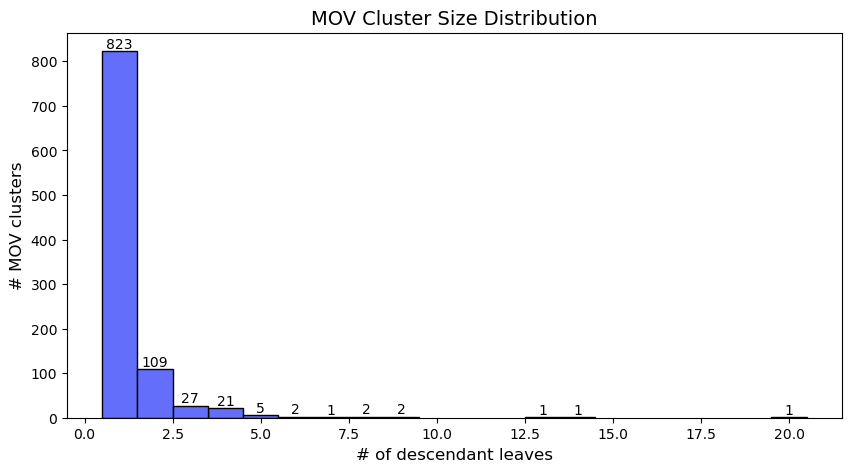

<Figure size 640x480 with 0 Axes>

In [61]:
# strict threshold MOV clusters

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

strict_mov_nodes = pd.read_csv("/Users/reem/merged_bte_mov_strict.tsv", sep="\t")


# size counts
size_counts = Counter(strict_mov_nodes["cluster_size"])

sizes = size_counts.keys()
counts = size_counts.values()

plt.figure(figsize=(10,5))

bars = plt.bar(
    sizes,
    counts,
    width=1.0,
    color="#636EFA",
    edgecolor="black"
)
x_values = np.arange(len(sizes))
plt.xlabel("# of descendant leaves", fontsize=12)
plt.ylabel("# MOV clusters", fontsize=12)
plt.title("MOV Cluster Size Distribution", fontsize=14)

ax = plt.gca()
ax.bar_label(bars, label_type='edge', color='black')     
plt.show()

plt.tight_layout()
plt.savefig("/Users/reem/new_figs/MOV_cluster_size_distribution.svg")
plt.show()
